# Statistical analysis of aggregate data

Imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np
from scipy.io import loadmat
import json
import jsonpickle as pickle

In [2]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf

torch threads 1
Running on device cpu


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set global variables and propertes

In [3]:
raw_data_fname_str = ""
raw_data_folder = "raw_data"
choice_data_folder = os.path.join(raw_data_folder, "choices")
questionnaire_data_folder = os.path.join(raw_data_folder, "questionnaires")

results_folder = os.path.join("results")
processed_data_folder = os.path.join("processed_data")

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

annotated_data_fname = "annotated_data.csv"
annotated_data_file = os.path.join(processed_data_folder, annotated_data_fname)

mask_file_name = "mask.pkl"
mask_file = os.path.join(processed_data_folder, mask_file_name)

structured_data_fname = "structured_data.pkl"
structured_data_file = os.path.join(processed_data_folder, structured_data_fname)

statistics_folder = os.path.join(results_folder, "statistics")

scores_fname = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_fname)

statistics_folder = os.path.join(results_folder, "statistics")

In [4]:
n_subjects = 206

### read summary data

In [5]:
annotated_df = pd.read_csv(annotated_data_file)

In [6]:
annotated_df

,Unnamed: 0,subject,trial,valid,choices first stage,choices second stage,RTs first stage,RTs second stage,states first stage,states second stage,outcomes first stage,outcomes second stage,common,stayed,rewarded
0,0,0,0,True,0,1,1404,1044,0,1,1,0,common,True,unrewarded
1,1,0,1,True,0,0,858,496,0,1,1,2,common,True,rewarded
2,2,0,2,True,0,0,496,508,0,1,1,2,common,True,rewarded
3,3,0,3,True,0,1,405,1372,0,2,1,2,rare,True,rewarded
4,4,0,4,True,0,0,469,428,0,1,1,0,common,False,unrewarded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30895,30895,205,120,True,0,1,464,1165,0,2,1,2,rare,False,rewarded
30896,30896,205,121,True,1,1,1102,1077,0,2,1,0,common,True,unrewarded
30897,30897,205,122,True,1,1,921,688,0,2,1,2,common,False,rewarded
30898,30898,205,123,True,0,0,915,1407,0,1,1,2,common,True,rewarded


In [7]:
second_level_vals = []
stayed_dict = {"subject": [], "rewarded": [], "common": [], "stayed": []}
stayed_df = pd.DataFrame(stayed_dict)

for i in range(n_subjects):

    second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())

    second_level_dict = {"subject": [i]*4, "rewarded": ["rewarded", "unrewarded"]*2, 
                            "common": ["common"]*2+["rare"]*2, "stayed": second_level_vals[-1].values}

    stayed_df = pd.concat([stayed_df, pd.DataFrame(second_level_dict)], join="inner")

/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupb

/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupby(["common", "rewarded"])["stayed"].mean())
/tmp/ipykernel_352107/518048712.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  second_level_vals.append(annotated_df[annotated_df["subject"]==i][annotated_df["valid"]==True].groupb

In [8]:
stayed_df

,subject,rewarded,common,stayed
0,0.0,rewarded,common,0.862069
1,0.0,unrewarded,common,0.750000
2,0.0,rewarded,rare,0.612903
3,0.0,unrewarded,rare,0.857143
0,1.0,rewarded,common,0.421875
...,...,...,...,...
3,204.0,unrewarded,rare,0.800000
0,205.0,rewarded,common,0.500000
1,205.0,unrewarded,common,0.466667
2,205.0,rewarded,rare,0.466667


In [12]:
sub_df = stayed_df[stayed_df["rewarded"]=="rewarded"]

In [13]:
sub_df

,subject,rewarded,common,stayed
0,0.0,rewarded,common,0.862069
2,0.0,rewarded,rare,0.612903
0,1.0,rewarded,common,0.421875
2,1.0,rewarded,rare,0.583333
0,2.0,rewarded,common,0.704545
...,...,...,...,...
2,203.0,rewarded,rare,0.904762
0,204.0,rewarded,common,0.882353
2,204.0,rewarded,rare,0.952381
0,205.0,rewarded,common,0.500000


In [15]:
summary_dict = {}

rewarded = stayed_df[stayed_df["rewarded"]=="rewarded"]
unrewarded = stayed_df[stayed_df["rewarded"]=="unrewarded"]
# common = stayed_df[stayed_df["common"]=="common"]
# rare = stayed_df[stayed_df["common"]=="rare"]

summary_dict["rewarded common"] = rewarded[rewarded["common"]=="common"]["stayed"].values
summary_dict["rewarded rare"] = rewarded[rewarded["common"]=="rare"]["stayed"].values
summary_dict["unrewarded common"] = unrewarded[unrewarded["common"]=="common"]["stayed"].values
summary_dict["unrewarded rare"] = unrewarded[unrewarded["common"]=="rare"]["stayed"].values

summary_stayed_arr = [summary_dict["rewarded common"], summary_dict["rewarded rare"], summary_dict["unrewarded common"], summary_dict["unrewarded rare"]]

### plot repetitions of first stage actions

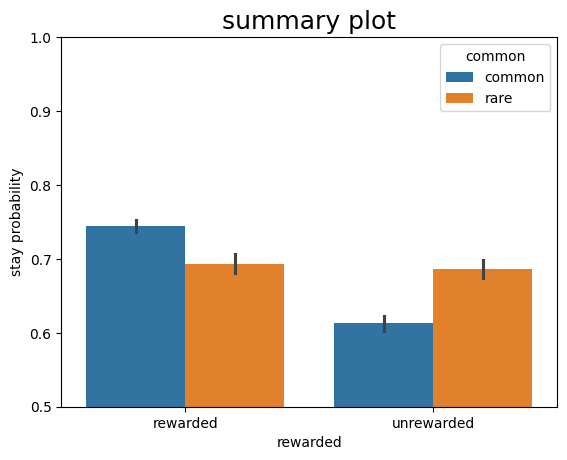

In [16]:
plt.figure()
g = sns.barplot(data=annotated_df, x="rewarded", y="stayed", hue="common", order=["rewarded", "unrewarded"])
#g.set_xticklabels(names, rotation=45, horizontalalignment='right', fontsize=16)
plt.ylim([0.5,1])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("summary plot", fontsize=18)
plt.savefig(os.path.join(statistics_folder, "behavior_summary_second_level_df.svg"),dpi=300)
plt.ylabel("stay probability")
plt.show()

### calculate and plot scores

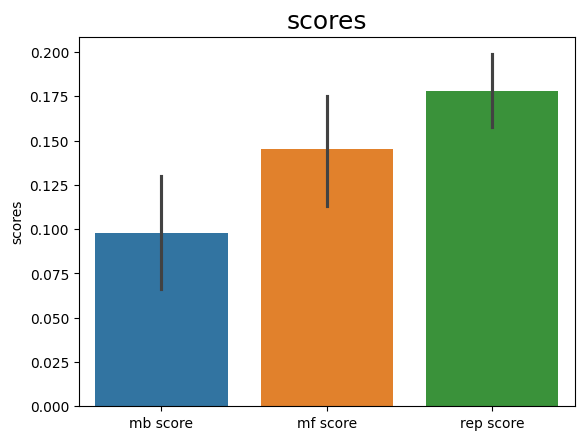

<Figure size 640x480 with 0 Axes>

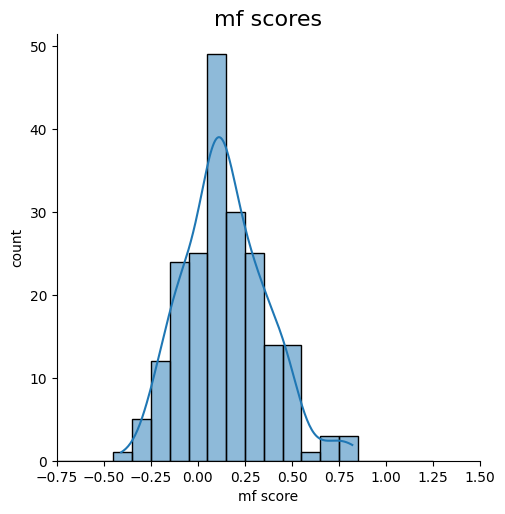

<Figure size 640x480 with 0 Axes>

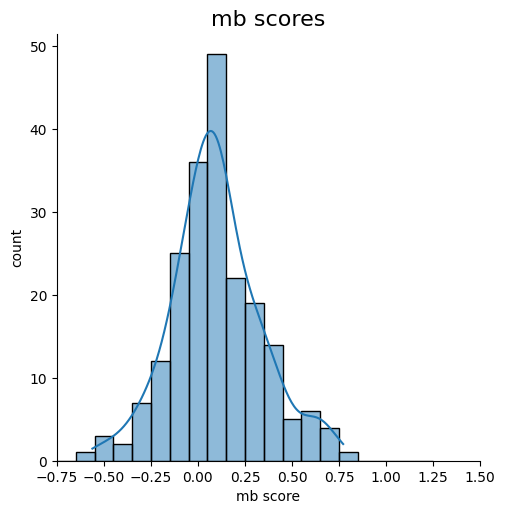

<Figure size 640x480 with 0 Axes>

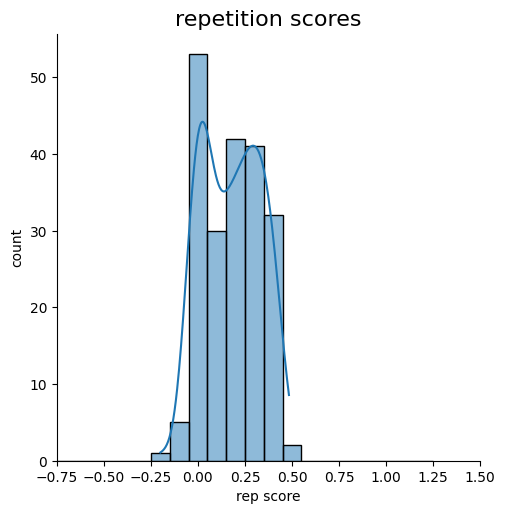

In [17]:
mf_score = summary_stayed_arr[0] + summary_stayed_arr[1] - summary_stayed_arr[2] - summary_stayed_arr[3]

mb_score = summary_stayed_arr[0] - summary_stayed_arr[1] - summary_stayed_arr[2] + summary_stayed_arr[3]

rep_score = (summary_stayed_arr[0] + summary_stayed_arr[1] + summary_stayed_arr[2] + summary_stayed_arr[3])/4 - 0.5

scores = pd.DataFrame({'mb score': mb_score, 'mf score': mf_score, "rep score": rep_score})

plt.figure()
g = sns.barplot(data=scores)
#plt.ylim([0,0.5])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("scores", fontsize=18)
plt.savefig(os.path.join(statistics_folder, "behavior_scores.svg"),dpi=300)
plt.ylabel("scores")
plt.show()

plt.figure()
sns.displot(data=scores, x="mf score", kde=True, binrange=[-0.75,1.25], bins=20)
plt.xlim([-0.75,1.5])
#plt.ylim([0,0.5])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("mf scores", fontsize=16)
plt.savefig(os.path.join(statistics_folder, "mf_scores.svg"),dpi=300)
plt.ylabel("count")
plt.show()

plt.figure()
sns.displot(data=scores, x="mb score", kde=True, binrange=[-0.75,1.25], bins=20)
plt.xlim([-0.75,1.5])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("mb scores", fontsize=16)
plt.savefig(os.path.join(statistics_folder, "mb_scores.svg"),dpi=300)
plt.ylabel("count")
plt.show()

plt.figure()
sns.displot(data=scores, x="rep score", kde=True, binrange=[-0.75,1.25], bins=20)
plt.xlim([-0.75,1.5])
# plt.yticks(np.arange(0,1.1,0.2),fontsize=16)
plt.title("repetition scores", fontsize=16)
plt.savefig(os.path.join(statistics_folder, "mb_scores.svg"),dpi=300)
plt.ylabel("count")
plt.show()

### check for relations between scores

In [18]:
#plt.figure()
#sns.jointplot(data=scores, x="mf score", y="mb score")
#plt.show()

<Figure size 640x480 with 0 Axes>

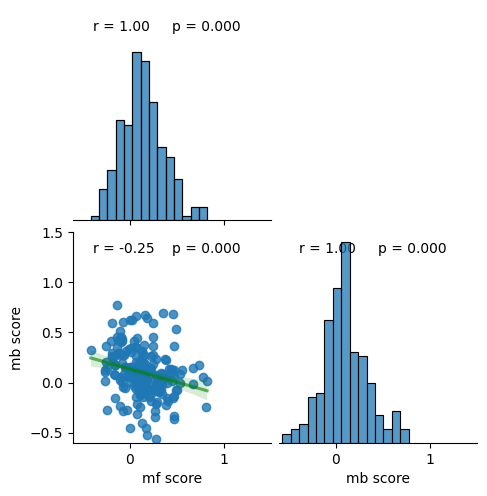

In [19]:
plt.figure()
vars_of_interest = ["mf score", "mb score"]
f = sns.pairplot(data=scores, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    vars=vars_of_interest)
f.map(tu.annot_corrfunc)
f.axes[1,0].set_xlim([-0.6, 1.5])
f.axes[1,0].set_ylim([-0.6, 1.5])
f.axes[1,1].set_xlim([-0.6, 1.5])
plt.savefig(os.path.join(statistics_folder, "scores.svg"))
plt.show()

### save scores to file

In [20]:
scores.to_csv(scores_file)